In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Analyzing the Impact of Weather on Delhi's Air Quality

## 1. Introduction and Problem Formulation
Delhi, the capital territory of India, consistently ranks among the most polluted cities globally. High concentrations of particulate matter (PM2.5 and PM10) pose a severe public health crisis, leading to respiratory and cardiovascular emergencies. 

While the sources of this pollution are well-documented (vehicular emissions, crop stubble burning, construction dust), meteorological conditions are a major contributing factor in severe smog events. Factors like wind speed, humidity, and temperature inversions dictate whether pollutants disperse into the upper atmosphere or become trapped at ground level.

### Project Objectives and Scope
This technical report explores the intersection of meteorology and urban pollution. To ensure a good analysis, this project uses **two independent data sources**:
1. **Air Quality Data:** Historical daily readings of pollutants and AQI from the Central Pollution Control Board (CPCB).
2. **Historical Weather Data:** Meteorological metrics including temperature, humidity, and wind speed.

**Our primary goals are to:**
1. Ingest, clean, and chronologically merge these two disparate datasets.
2. Perform Data Analysis to uncover statistical correlations between weather phenomena and hazardous AQI spikes.
3. Build a predictive data model to forecast air quality risks based on impending weather conditions.

In [12]:
# Load datasets
df_air_all_cities = pd.read_csv('../data/air_quality.csv')
df_weather = pd.read_csv('../data/delhi_weather.csv')

# We only want Delhi data to match our weather dataset
df_air = df_air_all_cities[df_air_all_cities['City'] == 'Delhi'].copy()

# Verify successful loading
print(f"Air Quality Data (Delhi only) Shape: {df_air.shape}")
print(f"Weather Data Shape: {df_weather.shape}\n")

print("--- First 3 rows of Air Quality Data ---")
display(df_air.head(3))

print("\n--- First 3 rows of Weather Data ---")
display(df_weather.head(3))

Air Quality Data (Delhi only) Shape: (2009, 16)
Weather Data Shape: (96432, 25)

--- First 3 rows of Air Quality Data ---


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate



--- First 3 rows of Weather Data ---


,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,2009-01-01 00:00:00,22,9,0.0,8.7,4,1,31,10:11 AM,09:57 PM,...,14,19,0,50,0.0,1016,10,10,331,12
1,2009-01-01 01:00:00,22,9,0.0,8.7,4,1,31,10:11 AM,09:57 PM,...,13,21,0,51,0.0,1016,10,10,329,13
2,2009-01-01 02:00:00,22,9,0.0,8.7,4,1,31,10:11 AM,09:57 PM,...,12,22,0,52,0.0,1016,9,10,327,13


## 2. Data Processing and Temporal Alignment

A common challenge in data science is integrating datasets with different granularities. 
* Our **Air Quality (AQI)** data is recorded at a **daily** level.
* Our **Weather** data is recorded at an **hourly** level.

To build a unified dataset, we must perform temporal alignment. We will extract the date from the hourly weather timestamps, group the weather data by day, and calculate the daily mean for each meteorological metric. Once both datasets share a uniform daily index, we can perform an inner join to merge them.

**Handling Missing Data:**
In time-series environmental data, gaps are common due to sensor downtime. We must handle these safely to prevent "data leakage" (using future data to inform past data). 
* For **weather metrics**, we will use Forward Fill (`ffill`), assuming weather conditions remain relatively stable during short sensor outages.
* For our **target variable (PM2.5)**, we will strictly drop any missing rows. We cannot fill this with future or past data without compromising the integrity of our predictive model.

In [13]:
# 1. Standardize Dates in Air Quality Data
df_air['Date'] = pd.to_datetime(df_air['Date'])

# 2. Standardize Dates in Weather Data
df_weather['date_time'] = pd.to_datetime(df_weather['date_time'])
df_weather['Date'] = df_weather['date_time'].dt.normalize()

# 3. Aggregate Weather Data to Daily Averages
daily_weather = df_weather.groupby('Date').mean(numeric_only=True).reset_index()

# 4. Merge the Datasets
df_merged = pd.merge(df_air, daily_weather, on='Date', how='inner')

# 5. Safely Handle Missing Values (Preventing Future Leakage)
weather_fill_cols = ['tempC', 'humidity', 'windspeedKmph', 'pressure', 'precipMM']
existing_cols = [col for col in weather_fill_cols if col in df_merged.columns] # Safety check
df_merged[existing_cols] = df_merged[existing_cols].ffill()

# If PM2.5 is missing, drop the row entirely.
df_merged.dropna(subset=['PM2.5'], inplace=True)

print(f"Final Merged Dataset Shape: {df_merged.shape}")
print("\n--- First 3 rows of Merged Data ---")
display(df_merged.head(3))

Final Merged Dataset Shape: (1825, 36)

--- First 3 rows of Merged Data ---


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,...,16.375000,9.958333,13.291667,38.875000,0.000000,1017.125,14.958333,10.000,66.750000,5.875000
1,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,...,12.958333,15.500000,62.375000,66.333333,0.008333,1019.250,12.791667,8.875,96.625000,9.916667
2,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,...,15.083333,7.500000,41.375000,83.500000,0.000000,1018.375,13.833333,9.000,123.083333,4.541667


## 3. Exploratory Data Analysis (EDA): Finding the Culprit

With our datasets successfully merged and cleaned, we can now investigate the mathematical relationships between weather conditions and air pollution. 

The most effective way to identify these relationships across multiple variables simultaneously is by calculating a **Correlation Matrix** and visualizing it as a heatmap. A correlation coefficient ranges from -1 to 1:
* **Negative Correlation (closer to -1):** As one variable goes up, the other goes down. (e.g., We expect high wind speed to correlate with lower pollution because it blows the smog away).
* **Positive Correlation (closer to 1):** Both variables move in the same direction. (e.g., We might see a positive correlation between humidity and AQI, as moisture can trap particulates in the air).
* **Zero Correlation (around 0):** No relationship at all.

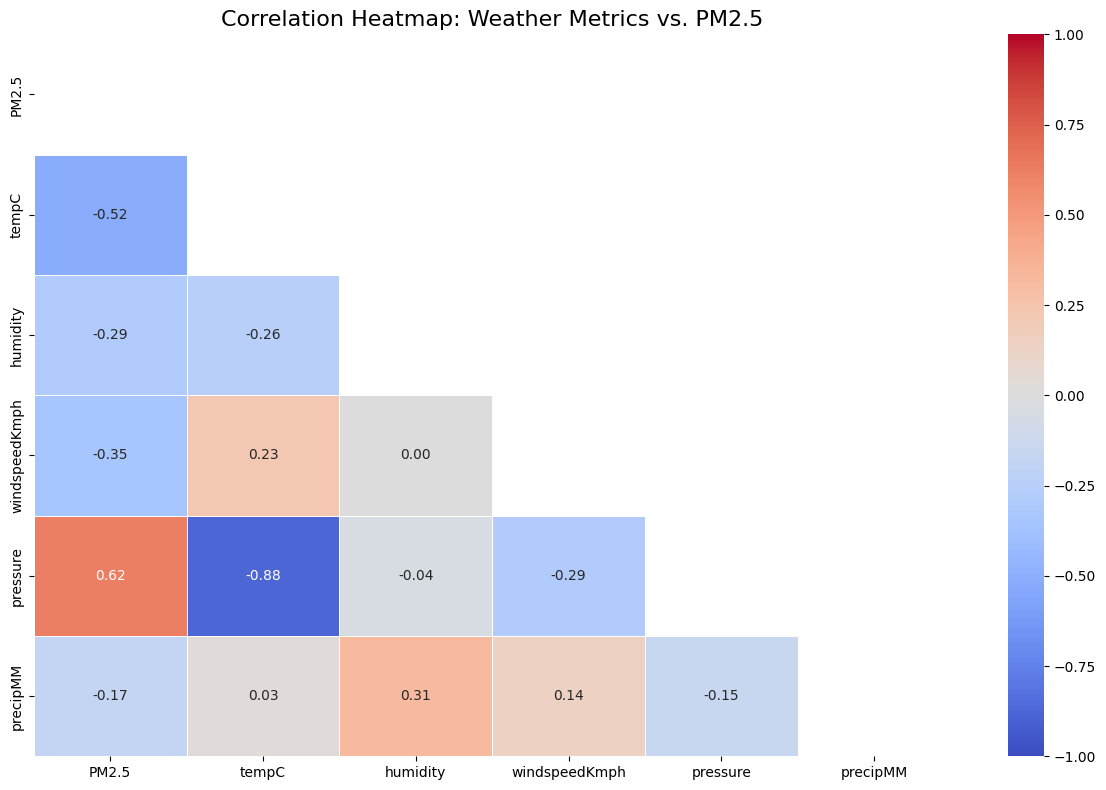

In [14]:
# 1. Isolate the key variables for a focused correlation matrix
# We focus on our target (PM2.5) and the primary weather indicators
eda_cols = ['PM2.5', 'tempC', 'humidity', 'windspeedKmph', 'pressure', 'precipMM']

# Safety check to only include columns that actually exist in the dataframe
existing_eda_cols = [col for col in eda_cols if col in df_merged.columns]

# 2. Calculate the correlation matrix
corr_matrix = df_merged[existing_eda_cols].corr()

# 3. Create a mask to hide the upper triangle.
# We do that because in an unmasked heatmap the top right half is a perfect mirror image to the bottom left half.
# This happens because the matrix compares every single variable agains every other variable.
# So it will compare Temperature and AQI and AQI and Temperature, but their correlation is exactly the same.
# This mask removes the duplicate comparison + the diagonal of perfect correlation.
# This is because the matrix is comparing Temperature to Temperature, Wind to Wind, etc.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))

# 4. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5
)

plt.title("Correlation Heatmap: Weather Metrics vs. PM2.5", fontsize=16)
plt.tight_layout()
plt.show()

### 3.1 Zooming In: Temperature vs. Particulate Matter (PM2.5)

The correlation heatmap revealed a notable negative correlation between **Temperature** and **PM2.5** levels. In environmental science, this is often linked to a phenomenon called *thermal inversion*. During winter months, cold air is trapped close to the ground by a layer of warmer air above it. This acts like a lid, preventing vehicular and industrial emissions from dispersing.

To visualize this relationship, we will plot Temperature against PM2.5 using a scatter plot and a trendline.

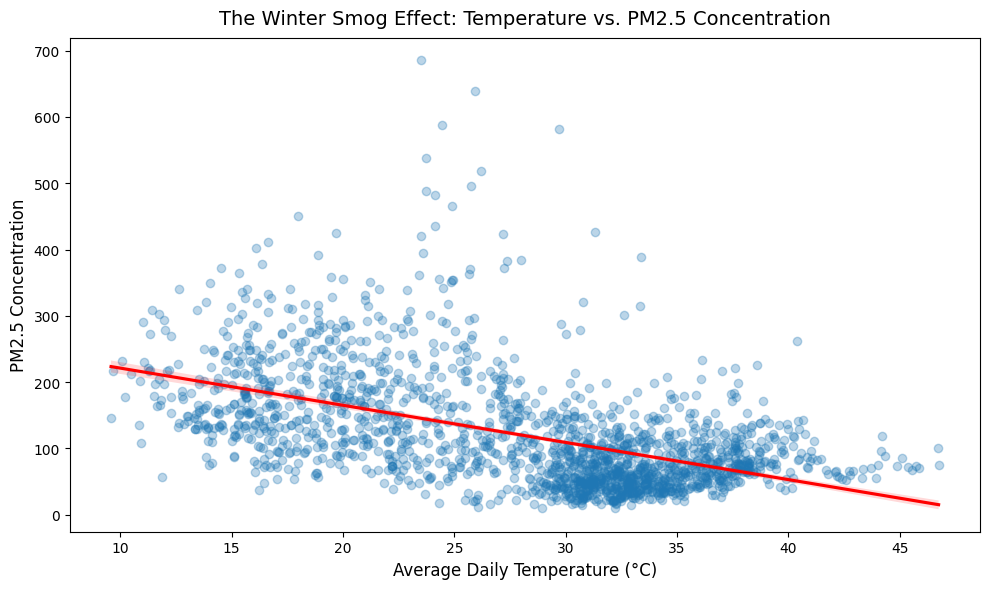

In [ ]:
plt.figure(figsize=(10, 6))

# Use Seaborn's regplot to draw the scatter points and a trendline
sns.regplot(
    x='tempC',
    y='PM2.5',
    data=df_merged,
    scatter_kws={'alpha': 0.3},  # Make dots somewhat transparent so we can see density
    line_kws={'color': 'red'}
)

# Add labels and titles
plt.title('The Winter Smog Effect: Temperature vs. PM2.5 Concentration', fontsize=14, pad=10)
plt.xlabel('Average Daily Temperature (°C)', fontsize=12)
plt.ylabel('PM2.5 Concentration', fontsize=12)

plt.tight_layout()
plt.show()

### 3.2 Time-Series Analysis: The Seasonal Cycle

Pollution in Delhi is not a static problem; it is highly seasonal. While our scatter plot showed a general inverse relationship, visualizing these metrics chronologically over the course of a year paints a much clearer picture.

To do this, we will extract the "Month" from our timestamps, group the data, and calculate the average PM2.5 and average Temperature for each month. We will then plot them on a dual-axis chart to see exactly when the "smog season" begins and ends.

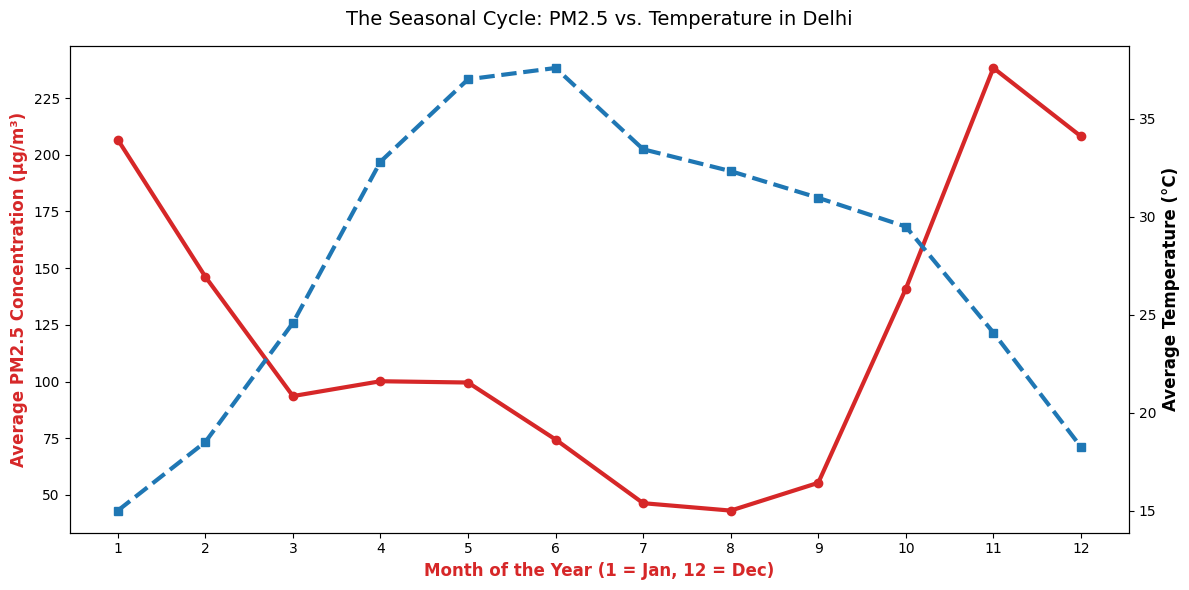

In [16]:
# 1. Extract the month from our Date column
df_merged["Month"] = df_merged["Date"].dt.month

# 2. Group by Month and calculate the mean for PM2.5 and temperature
monthly_data = df_merged.groupby('Month')[['PM2.5', 'tempC']].mean().reset_index()

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:red'
ax1.set_xlabel('Month of the Year (1 = Jan, 12 = Dec)', color=color1, fontsize=12, fontweight='bold')
ax1.set_ylabel('Average PM2.5 Concentration (µg/m³)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(monthly_data['Month'], monthly_data['PM2.5'], color=color1, marker='o', linewidth=3, label='PM2.5')
ax1.grid(False)

# Make a second Y axis, sharing the same X axis
ax2 = ax1.twinx()

ax2.set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
ax2.plot(monthly_data['Month'], monthly_data['tempC'], marker='s', linewidth=3, linestyle='--', label='Temperature')
ax2.tick_params(axis='y')
ax2.grid(False)

plt.title('The Seasonal Cycle: PM2.5 vs. Temperature in Delhi', fontsize=14, pad=15)
plt.xticks(range(1, 13)) # Ensure all 12 months show up on the bottom
fig.tight_layout()  # Prevents labels from getting cut off

plt.show()

## 4. Feature Engineering for Machine Learning

Before feeding our data into a predictive model, we need to engineer new features that provide temporal context. A machine learning algorithm looks at one row at a time. If we only give it "today's temperature", it doesn't know if a cold front just moved in or if it's been cold all week.

We will create three new contextual features:
1. **Lagged PM2.5 (`PM2.5_Yesterday`):** The pollution level from the previous day. Smog accumulates, so yesterday's air quality is a massive predictor of today's air quality.
2. **Temperature Change (`Temp_Change`):** The difference in temperature between yesterday and today. Sudden drops can trigger thermal inversions.
3. **Rolling Average (`PM2.5_3Day_Avg`):** A 3-day moving average to smooth out daily anomalies and capture the immediate trend.

In [17]:
# 1. Create Lagged Features 
df_merged['PM2.5_Yesterday'] = df_merged['PM2.5'].shift(1)
df_merged['Temp_Change'] = df_merged['tempC'].diff()

# 2. Create Rolling Window Safely (Shift first, then roll to prevent target leakage!)
df_merged['PM2.5_3Day_Avg'] = df_merged['PM2.5'].shift(1).rolling(window=3).mean()

# 3. Drop the resulting NaNs caused by the .shift() and .rolling() operations
df_merged.dropna(subset=['PM2.5_Yesterday', 'Temp_Change', 'PM2.5_3Day_Avg'], inplace=True)

# Let's look at our newly engineered columns
feature_check_cols = ['Date', 'PM2.5', 'PM2.5_Yesterday', 'tempC', 'Temp_Change', 'PM2.5_3Day_Avg']
print("--- Engineered Features ---")
display(df_merged[feature_check_cols].head(5))

--- Engineered Features ---


,Date,PM2.5,PM2.5_Yesterday,tempC,Temp_Change,PM2.5_3Day_Avg
3,2015-01-04,151.84,87.18,13.416667,-0.416667,195.526667
4,2015-01-05,146.60,151.84,13.291667,-0.125000,141.733333
5,2015-01-06,149.58,146.60,13.000000,-0.291667,128.540000
6,2015-01-07,217.87,149.58,12.208333,-0.791667,149.340000
7,2015-01-08,229.90,217.87,11.083333,-1.125000,171.350000


## 5. Machine Learning Preparation: Splitting and Feature Selection

Before we train our predictive model, we must prepare our data through two critical steps:

1. **Chronological Train/Test Split:** We need to evaluate our model on data it has never seen before. Because we are dealing with time-series data, we **cannot randomly shuffle** our rows. Doing so would cause "data leakage" (using future knowledge to predict the past). Instead, we will train our model on the first 80% of our timeline and test it on the final 20%.
2. **Explicit Feature Selection:** To prevent target leakage, we explicitly define our input features. We exclude same-day pollutants (like PM10 or AQI) to ensure the model learns from the weather and past history, rather than "cheating" by looking at other simultaneous pollution metrics. We will create two feature sets (Weather-Only vs. Weather + History) to compare their predictive power.

In [18]:
# 1. EXPLICIT Feature Selection (Prevents leaking same-day pollutants like PM10 or NO2)
weather_cols = ['tempC', 'humidity', 'windspeedKmph', 'pressure', 'precipMM', 'Temp_Change']
history_cols = ['PM2.5_Yesterday', 'PM2.5_3Day_Avg']

# Create two feature sets to compare
X_weather_only = df_merged[weather_cols]
X_full = df_merged[weather_cols + history_cols]
y = df_merged['PM2.5']

# 2. Train/Test Split
# We split both feature sets using the exact same chronological index
split_idx = int(len(df_merged) * 0.8)

X_train_weather, X_test_weather = X_weather_only.iloc[:split_idx], X_weather_only.iloc[split_idx:]
X_train_full, X_test_full = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on the first {len(y_train)} days, testing on {len(y_test)} days.")

Training on the first 1457 days, testing on 365 days.


## 6. Predictive Modeling: Random Forest Regressor

To predict PM2.5 levels, we will use a **Random Forest Regressor**. 

A Random Forest is an "ensemble" machine learning method. Instead of relying on a single mathematical formula, it builds dozens (or hundreds) of individual "Decision Trees" during training. Each tree looks at different subsets of our weather and historical data to make a prediction, and the forest ultimately averages all those individual predictions together.

**Why Random Forest?**
* **Non-linear relationships:** Weather patterns are complex. Random forests excel at capturing non-linear thresholds (e.g., thermal inversions that only happen at specific temperatures).
* **Robustness:** By averaging many trees together, the model is less likely to "overfit" (memorize the training data) and performs better on unseen future data.

In [ ]:
# 1. Train Models
print("Training models...")
rf_weather = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_weather.fit(X_train_weather, y_train)

rf_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_train_full, y_train)

# 2. Generate Predictions
y_pred_weather = rf_weather.predict(X_test_weather)
y_pred_full = rf_full.predict(X_test_full)

print("Training complete!")

Training models...
Training complete!


## 7. Model Evaluation and Validation

To determine how well our models learned the underlying patterns, we must evaluate them against a baseline (a persistence baseline that predicts each day's PM2.5 using the previous day's PM2.5). We will use standard regression metrics:

* **Mean Absolute Error (MAE):** The average absolute magnitude of the errors.
  $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* **Root Mean Squared Error (RMSE):** Penalizes larger errors more heavily by squaring them before averaging. 
  $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
* **R-squared ($R^2$):** Represents the proportion of variance in the target variable that can be explained by our features.
  $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

--- Baseline (Persistence) ---
MAE: 28.21 µg/m³ | RMSE: 46.82 µg/m³ | R²: 0.70

--- Model 1: Weather Only ---
MAE: 44.49 µg/m³ | RMSE: 65.43 µg/m³ | R²: 0.42

--- Model 2: Weather + Pollution History ---
MAE: 25.08 µg/m³ | RMSE: 42.33 µg/m³ | R²: 0.76



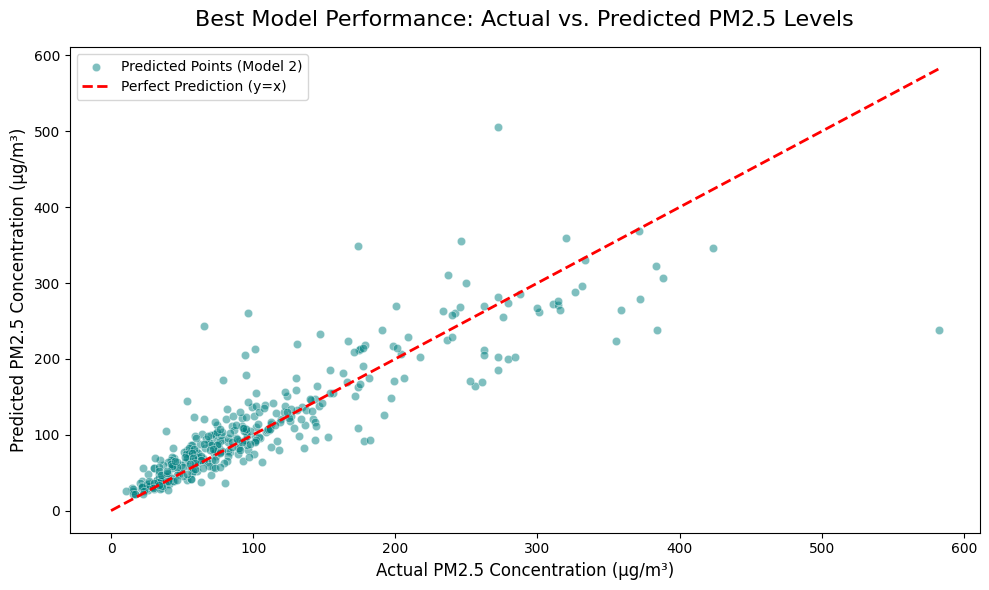

In [ ]:
# 1. Define an evaluation function
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    print(f"--- {name} ---")
    print(f"MAE: {mae:.2f} µg/m³ | RMSE: {rmse:.2f} µg/m³ | R²: {r2:.2f}\n")

# 2. Baseline: predict each day's PM2.5 using the previous day's PM2.5
baseline_pred = X_test_full['PM2.5_Yesterday']
evaluate_model("Baseline (Persistence)", y_test, baseline_pred)

# 3. Weather Only Model
evaluate_model("Model 1: Weather Only", y_test, y_pred_weather)

# 4. Weather + History Model
evaluate_model("Model 2: Weather + Pollution History", y_test, y_pred_full)

# 5. Visualize the Best Model (Model 2) vs Actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_full, alpha=0.5, color='teal', label='Predicted Points (Model 2)')

# Draw the "Perfect Prediction" reference line
max_val = max(y_test.max(), y_pred_full.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Best Model Performance: Actual vs. Predicted PM2.5 Levels', fontsize=16, pad=15)
plt.xlabel('Actual PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion and Future Work

This project investigated the relationship between meteorological conditions and winter smog in Delhi. Through Exploratory Data Analysis, the data suggested a severe inverse relationship between temperature drops and PM2.5 spikes. 

To rigorously test the predictive power of meteorology, we evaluated a persistence baseline (predicting each day's PM2.5 using the previous day's reading) against two Random Forest models. The results were revealing:

* **Baseline (Persistence):** Demonstrated strong performance, indicating that PM2.5 levels are highly persistent and accumulate over time.
* **Model 1 (Weather-Only):** Underperformed the persistence baseline. This indicates that while weather dictates atmospheric dispersion, meteorological data alone is not sufficient to reliably predict actual particulate loads.
* **Model 2 (Weather + History):** Performed the best overall. By combining recent pollution history with impending weather conditions, the model successfully outperformed the baseline.

**Final Takeaway:** Weather alone does not generate smog, but it acts as a critical modulator. The most accurate predictive strategy relies on knowing the existing pollution load and using meteorology to forecast whether that load will disperse or stagnate.

**Future iterations of this project could improve by:**
1. Integrating satellite data for active fire counts to track external variables like crop stubble burning upwind.
2. Adding categorical features for local holidays to account for human-driven anomalies (e.g., festival fireworks).

## 9. References and Sources

To ensure academic integrity, the methodologies, code structures, and datasets in this report were informed by the following resources:

**Datasets:**
* Rao, R. (2020). *Air Quality Data in India (2015-2020)*. Kaggle. 
* Soneji, H. (2022). *Historical Weather Data for Indian Cities*. Kaggle.

**Tools and Libraries:**
* Pandas Development Team. (2023). *pandas-dev/pandas: Pandas*. Zenodo.
* Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. Computing in Science & Engineering.
* Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, pp. 2825-2830.